<a href="https://colab.research.google.com/github/RRADJon/TEMPO/blob/main/pyPBPK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#@title System Setup & Simulation
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#Tissue Composition Data ---
tissue_composition = {
    "liver":    {"f_w": 0.72, "f_nl": 0.02, "f_ph": 0.025, "f_p": 0.18, "pH": 7.2},
    "muscle":   {"f_w": 0.76, "f_nl": 0.01, "f_ph": 0.01,  "f_p": 0.18, "pH": 7.0},
    "adipose":  {"f_w": 0.15, "f_nl": 0.79, "f_ph": 0.002, "f_p": 0.04, "pH": 7.4},
    "brain":    {"f_w": 0.77, "f_nl": 0.05, "f_ph": 0.04,  "f_p": 0.10, "pH": 7.1},
    "kidney":   {"f_w": 0.77, "f_nl": 0.01, "f_ph": 0.02,  "f_p": 0.18, "pH": 7.2},
    "stomach":  {"f_w": 0.72, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.18, "pH": 7.2},
    "duodenum": {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
    "jejunum":  {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
    "ileum":    {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
}

#Physiological & Model Functions ---

def kp_rodgers_rowland(drug, tissue_name):
    if tissue_name not in tissue_composition: return 1.2
    comp = tissue_composition[tissue_name]
    logP = drug["physchem"]["logP"]
    pKa = drug["physchem"].get("pKa", None)
    fu = drug["fu"]
    is_base = drug["physchem"].get("is_base", True)

    P = 10**logP
    pH_t, pH_p = comp["pH"], 7.4

    if pKa:
        if is_base:
            ratio = (1 + 10**(pKa - pH_t)) / (1 + 10**(pKa - pH_p))
        else:
            ratio = (1 + 10**(pH_t - pKa)) / (1 + 10**(pH_p - pKa))
    else:
        ratio = 1.0

    return (comp["f_w"] * ratio) + (comp["f_nl"] * P) + (comp["f_ph"] * P * 0.3) + (comp["f_p"] * 0.05)

def calculate_effective_mw(base_mw, n_f=0, n_cl=0, n_br=0, n_i=0):
    halogens = {'F': 18.99, 'Cl': 35.45, 'Br': 79.90, 'I': 126.90}
    return base_mw + (n_f * halogens['F']) + (n_cl * halogens['Cl']) + \
           (n_br * halogens['Br']) + (n_i * halogens['I'])

def blood_to_plasma_ratio(logP):
    """
    Simple empirical approximation.
    PK-Sim typically ranges 0.8–1.4 for most drugs.
    """
    return max(0.6, 1.0 + 0.4 * logP)

def get_fixed_physiology(base_physiology, weight=70):
    phys = {"weight": weight}
    ratio = weight / 70
    phys["cardiac_output"] = base_physiology["cardiac_output"] * (ratio ** 0.75)
    phys["blood"] = {k: v * ratio for k, v in base_physiology["blood"].items()}
    phys["organs"] = {}
    total_frac = sum(p["Q_frac"] for p in base_physiology["organs"].values() if p["Q_frac"] is not None)

    for organ, props in base_physiology["organs"].items():
        phys["organs"][organ] = props.copy()
        phys["organs"][organ]["V"] *= ratio
        if props.get("Q_frac") is not None:
            phys["organs"][organ]["Q"] = phys["cardiac_output"] * (props["Q_frac"] / total_frac)

    phys["organs"]["rest"]["Q"] = phys["cardiac_output"] - sum(o.get("Q", 0) for o in phys["organs"].values() if "Q" in o)
    return phys

def calculate_half_life(t, c):
    """Estimates half-life from the terminal elimination phase."""
    try:
        max_idx = np.argmax(c)
        # Look at the curve after Cmax
        t_post_cmax = t[max_idx:]
        c_post_cmax = c[max_idx:]

        # Only take points where concentration is significant (above 10% of Cmax)
        mask = c_post_cmax > (np.max(c) * 0.1)
        if sum(mask) < 2: return np.nan

        # Linear regression on log-transformed data: ln(C) = -ke * t + ln(C0)
        slope, intercept = np.polyfit(t_post_cmax[mask], np.log(c_post_cmax[mask] + 1e-9), 1)
        ke = -slope
        if ke <= 0: return np.nan
        return np.log(2) / ke
    except:
        return np.nan

#ODE System ---

physiology_base = {
    "cardiac_output": 420,
    "organs": {
        "liver":   {"V": 1.8, "Q_frac": 0.25}, "kidney":  {"V": 0.31, "Q_frac": 0.195},
        "stomach": {"V": 0.5, "Q_frac": 0.01}, "duodenum":{"V": 0.3, "Q_frac": 0.015},
        "jejunum": {"V": 0.6, "Q_frac": 0.035}, "ileum":   {"V": 0.6, "Q_frac": 0.03},
        "muscle":  {"V": 29,  "Q_frac": 0.145}, "adipose": {"V": 18,  "Q_frac": 0.05},
        "brain":   {"V": 1.4, "Q_frac": 0.08},  "rest":    {"V": 15,  "Q_frac": None}
    },
    "blood": {"V_art": 1.5, "V_ven": 3.0}
}

state_names = ["stomach_lumen", "duodenum_lumen", "jejunum_lumen", "ileum_lumen",
               "liver", "kidney", "stomach", "duodenum", "jejunum", "ileum",
               "muscle", "adipose", "brain", "rest", "arterial", "venous", "cm_absorbed"]
state_index = {name: i for i, name in enumerate(state_names)}
GI_segments = ["stomach", "duodenum", "jejunum", "ileum"]
GI_LUMEN_VOLUMES = {"stomach": 0.15, "duodenum": 0.05, "jejunum": 0.13, "ileum": 0.18}

def solve_multi_dose(pbpk_ode, y0, phys, drug, t_eval, dose_times, route):
    """
    Handles repeated dosing (oral or IV) by restarting the ODE between doses.
    """
    y_current = y0.copy()
    full_t = []
    full_y = []

    t_end = t_eval[-1]
    dose_times = sorted([t for t in dose_times if t < t_end]) + [t_end]

    for i in range(len(dose_times) - 1):
        t_start = dose_times[i]
        t_next = dose_times[i + 1]

        # ---- Administer dose ----
        if i > 0 or t_start == 0:
            if route == "oral":
                y_current[state_index["stomach_lumen"]] += drug["dose_mg"]
            elif route == "iv":
                y_current[state_index["venous"]] += drug["dose_mg"]

        t_span = [t_start, t_next]
        t_seg = t_eval[(t_eval >= t_start) & (t_eval <= t_next)]

        if len(t_seg) > 0:
            sol = solve_ivp(
                pbpk_ode,
                t_span,
                y_current,
                t_eval=t_seg,
                args=(phys, drug),
                method="LSODA"
            )

            full_t.extend(sol.t)
            full_y.append(sol.y)
            y_current = sol.y[:, -1]

    return np.hstack(full_y)

def pbpk_ode(t, y, phys, drug):

    dydt = np.zeros(len(state_names))

    Rbp = drug["Rbp"]
    C_art = (y[state_index["arterial"]] / phys["blood"]["V_art"]) / Rbp
    C_ven = (y[state_index["venous"]] / phys["blood"]["V_ven"]) / Rbp

    CL_liver = (drug["CL_liver_ml_min_kg"] * phys["weight"] * 60) / 1000
    CL_kidney = (drug["CL_kidney_ml_min_kg"] * phys["weight"] * 60) / 1000

    portal_flow_mass = 0.0
    T_rates = {"stomach": 0.2, "distal": 2.0}

    # --- GI SEGMENTS ---
    for i, seg in enumerate(GI_segments):

        l_idx = state_index[seg + "_lumen"]
        t_idx = state_index[seg]
        V_lum = GI_LUMEN_VOLUMES[seg]

        A_dissolved = min(y[l_idx], drug["solubility_mg_L"] * V_lum)
        abs_rate = drug["KA"] * A_dissolved

        out_rate = T_rates["stomach"] if seg == "stomach" else T_rates["distal"]
        in_flow = 0.0 if i == 0 else (
            T_rates["stomach"] if i == 1 else T_rates["distal"]
        ) * y[state_index[GI_segments[i-1] + "_lumen"]]

        dydt[l_idx] = in_flow - abs_rate - (out_rate * y[l_idx])
        dydt[state_index["cm_absorbed"]] += abs_rate

        Q = phys["organs"][seg]["Q"]
        V = phys["organs"][seg]["V"]
        Kp = drug["Kp_map"][seg]

        C_ven_seg = (y[t_idx] / V) / Kp
        dydt[t_idx] = abs_rate + Q * (C_art - C_ven_seg)

        portal_flow_mass += Q * C_ven_seg

    # --- SYSTEMIC ORGANS ---
    venous_return = 0.0

    for organ in ["liver", "kidney", "muscle", "adipose", "brain", "rest"]:

        o_idx = state_index[organ]
        Q = phys["organs"][organ]["Q"]
        V = phys["organs"][organ]["V"]
        Kp = drug["Kp_map"][organ]

        C_org = y[o_idx] / V
        C_ven_org = C_org / Kp

        if organ == "liver":

            Q_liver = phys["organs"]["liver"]["Q"]
            Q_portal = sum(phys["organs"][s]["Q"] for s in GI_segments)
            Q_total_liver = Q_liver + Q_portal

            E_h = CL_liver / (Q_total_liver + CL_liver)
            elim = Q_total_liver * E_h * C_ven_org

            dydt[o_idx] = (
                (Q_liver * C_art)
                + portal_flow_mass
                - (Q_total_liver * C_ven_org)
                - elim
            )

            venous_return += Q_total_liver * C_ven_org

        elif organ == "kidney":

            # Flow-limited renal elimination
            elim = CL_kidney * C_ven_org
            dydt[o_idx] = Q * (C_art - C_ven_org) - elim

            venous_return += Q * C_ven_org

        else:

            dydt[o_idx] = Q * (C_art - C_ven_org)
            venous_return += Q * C_ven_org

    # --- BLOOD ---
    dydt[state_index["venous"]] = venous_return - phys["cardiac_output"] * C_ven
    dydt[state_index["arterial"]] = phys["cardiac_output"] * (C_ven - C_art)

    return dydt

/tmp/ipykernel_302/23612965.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC = np.trapz(conc, t_eval)


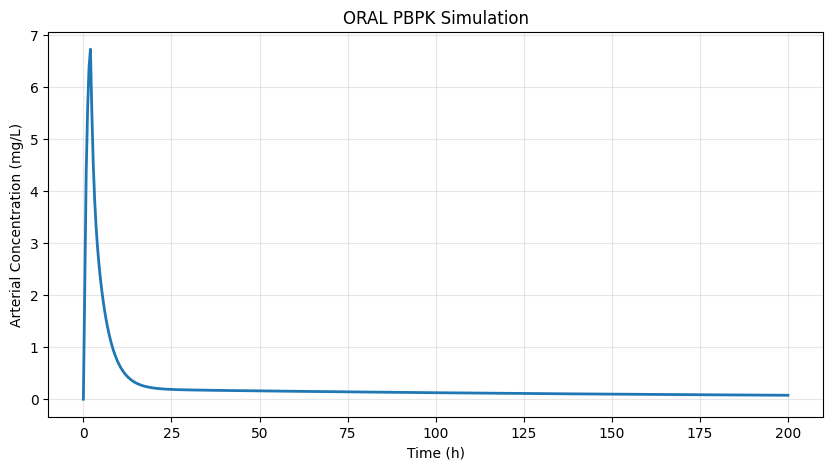

--- Results for User_Defined_Drug ---
Cmax: 6.7182 mg/L
AUC: 52.21 mg*h/L
Bioavailability: 100.00%
Fu: 0.1
logP/logD: 2.16
T1/2: 2.559680025646194 hrs


In [11]:
#@title Main Execution

#@markdown ### Parameter Mode
parameter_mode = "Manual Entry" #@param ["Manual Entry","Generate from SMILES"]

#@markdown ### If generating parameters, enter SMILES
smiles_input = "CC(=O)NC1=CC=C(C=C1)O" #@param {type:"string"}

#@markdown ### Individual
individual_weight = 75 #@param {type:"number"}
dose_mg_per_kg = 10 #@param {type:"number"}
route = "oral" #@param ["oral","iv"]
repeat_doses = False #@param {type:"boolean"}
dose_interval = 0 #@param {type:"number"}
simulation_time_hr = 200 #@param {type:"number"}

#@markdown ### Manual Drug Parameters (ignored if SMILES mode)
mw_base = 416.5 #@param {type:"number"}
fraction_unbound = 0.1 #@param {type:"number"}
solubility = 34 #@param {type:"number"}
permeability_keff = 0.8 #@param {type:"number"}
renal_clearance = 0.5 #@param {type:"number"}
liver_clearance = 4.5 #@param {type:"number"}
lipophilicity = 2.16 #@param {type:"number"}
pKa_in = 6.5 #@param {type:"number"}
is_base = True #@param {type:"boolean"}


# Hybrid SMILES ADMET Parameter Generation

if parameter_mode == "Generate from SMILES":
    !pip install rdkit transformers --quiet
    import numpy as np
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
    from transformers import AutoTokenizer, AutoModel
    import torch

    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None:
        raise ValueError("Invalid SMILES")

    # Basic RDKit descriptors
    mw_base = Descriptors.MolWt(mol)
    logP = Crippen.MolLogP(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    aromatic_atoms = sum(a.GetIsAromatic() for a in mol.GetAtoms())
    heavy_atoms = mol.GetNumHeavyAtoms()
    aromatic_fraction = aromatic_atoms / max(1, heavy_atoms)


    if is_base:
        lipophilicity = logP - np.log10(1 + 10**(7.4 - pKa_in))
    else:
        lipophilicity = logP - np.log10(1 + 10**(pKa_in - 7.4))


    # ESOL Solubility Model, Delaney 2004
    logS = (0.16 - 0.63 * lipophilicity - 0.0062 * mw_base + 0.066 * rotb - 0.74 * aromatic_fraction)
    solubility = (10**logS) * mw_base * 1000  # mg/L
    solubility = max(solubility, 0.001)


    # Intestinal permeability, Caco-2 regression
    log10_peff = (-3.5 + 0.18 * lipophilicity - 0.01 * tpsa + 0.002 * rotb)
    permeability_keff = (10**log10_peff) * 60  # cm/min

    # Plasma protein binding, fraction unbound
    fraction_unbound = 1 / (1 + (0.3 * lipophilicity**2))
    fraction_unbound = np.clip(fraction_unbound, 0.001, 0.9)

    # Intrinsic clearance, empirical scaling
    CLint_pkCSM = 10**(0.45 * lipophilicity - 0.015 * tpsa + 0.2 * hbd - 1.3)
    CLint_classical = 10**(0.5 * lipophilicity - 1.2)

    CLint = np.mean([CLint_classical, CLint_pkCSM])
    hepatic_flow = 20  # ml/min/kg
    liver_clearance = (hepatic_flow * CLint/ (hepatic_flow + CLint))

    # Renal clearance, fu scaling
    renal_clearance = 0.1 + 0.5 * fraction_unbound

    # ChemBERTa Embedding
    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    inputs = tokenizer(smiles_input, return_tensors="pt")
    with torch.no_grad():
        embedding = model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]

    # apply small correction factors
    solubility *= 1 + (0.05 * embedding[0])
    permeability_keff *= 1 + (0.05 * embedding[1])
    liver_clearance *= 1 + (0.05 * embedding[2])

    # clamp values to realistic ranges
    solubility = float(np.clip(solubility, 0.001, 500000))
    permeability_keff = float(np.clip(permeability_keff, 0.001, 5))
    liver_clearance = float(np.clip(liver_clearance, 0.01, 25))
    renal_clearance = float(np.clip(renal_clearance, 0.01, 10))

    print("\n Predicted ADMET Parameters")
    print("MW:", round(mw_base,2))
    print("logD:", round(lipophilicity,2))
    print("TPSA:", round(tpsa,2))
    print("Solubility (mg/L):", round(solubility,2))
    print("Permeability (cm/min):", round(permeability_keff,4))
    print("Fraction unbound:", round(fraction_unbound,3))
    print("Liver CL (ml/min/kg):", round(liver_clearance,3))
    print("Renal CL (ml/min/kg):", round(renal_clearance,3))

# Continue PBPK Setup
eff_mw = mw_base
phys = get_fixed_physiology(physiology_base, individual_weight)
dose_mg = dose_mg_per_kg * individual_weight
dose_times = [0, 0+dose_interval, 0+dose_interval*2, 0+dose_interval*3] if dose_interval > 0 else [0]
permeability_ka = (2 * permeability_keff) / 1.5
permeability_ka *= 60

drug_input = {
    "name": "User_Defined_Drug",
    "physchem": {
        "logP": lipophilicity,
        "pKa": pKa_in,
        "is_base": is_base
    },
    "KA": permeability_ka,
    "solubility_mg_L": solubility,
    "CL_liver_ml_min_kg": liver_clearance,
    "CL_kidney_ml_min_kg": renal_clearance,
    "fu": fraction_unbound,
    "MW_eff": eff_mw,
    "dose_mg": dose_mg,
    "dose_times": dose_times,
    "route": route
}

drug_input["Kp_map"] = {org: kp_rodgers_rowland(drug_input, org) for org in phys["organs"]}
drug_input["Rbp"] = blood_to_plasma_ratio(lipophilicity)


# Run Simulation
t_eval = np.linspace(0, simulation_time_hr, 500)
y0 = np.zeros(len(state_names))
if repeat_doses:
    Y = solve_multi_dose(pbpk_ode, y0, phys, drug_input, t_eval, dose_times, route)
else:
    if route == "oral":
        y0[state_index["stomach_lumen"]] = dose_mg
    else:
        y0[state_index["venous"]] = dose_mg
    sol = solve_ivp(pbpk_ode, [0, simulation_time_hr], y0, args=(phys, drug_input), t_eval=t_eval, method="LSODA")
    Y = sol.y


# PK Output
conc = Y[state_index["arterial"]] / phys["blood"]["V_art"]
Cmax = np.max(conc)
AUC = np.trapz(conc, t_eval)
total_dose = dose_mg * len(dose_times)
F_abs = Y[state_index["cm_absorbed"]][-1] / total_dose
thalf_val = calculate_half_life(t_eval, conc)


# Plot
plt.figure(figsize=(10,5))
plt.plot(t_eval, conc, linewidth=2)
plt.xlabel("Time (h)")
plt.ylabel("Arterial Concentration (mg/L)")
plt.title(f"{route.upper()} PBPK Simulation")
plt.grid(alpha=0.3)
plt.show()

# Results
print(f"--- Results for {drug_input['name']} ---")
print(f"Cmax: {Cmax:.4f} mg/L")
print(f"AUC: {AUC:.2f} mg*h/L")
print(f"Bioavailability: {F_abs:.2%}")
print(f"Fu: {fraction_unbound}")
print(f"logP/logD: {lipophilicity}")
print(f"T1/2: {thalf_val} hrs")

In [17]:
#@title PBPK Tissue Output

# --- Plasma Concentration ---
conc_plasma = Y[state_index["arterial"]] / phys["blood"]["V_art"]
fu = drug_input["fu"]
MW = drug_input["MW_eff"]

# Convert plasma to unbound and molar
conc_plasma_unbound = conc_plasma * fu
conc_plasma_unbound_uM = (conc_plasma_unbound / MW) * 1000  # mg/L → µM

# Plasma Metrics
Cmax = np.max(conc_plasma)
AUC = np.trapz(conc_plasma, t_eval)

Cmax_unbound_uM = np.max(conc_plasma_unbound_uM)
AUC_unbound_uM = np.trapz(conc_plasma_unbound_uM, t_eval)

# --- Tissue Concentration Extraction ---
tissue_rows = []

for organ in phys["organs"].keys():

    if organ in state_index:
        idx = state_index[organ]
        V = phys["organs"][organ]["V"]

        Ct_total = Y[idx] / V
        Ct_unbound = Ct_total * fu
        Ct_unbound_uM = (Ct_unbound / MW) * 1000

        tissue_rows.append({
            "compound": drug_input["name"],
            "tissue": organ,
            "dose_mg": dose_mg,
            "route": route,
            "simulation_hours": t_eval[-1],
            "fu_plasma": fu,
            "Rbp": drug_input["Rbp"],
            "Cmax_total_mg_L": np.max(Ct_total),
            "AUC_total_mg_h_L": np.trapz(Ct_total, t_eval),
            "Cmax_unbound_uM": np.max(Ct_unbound_uM),
            "AUC_unbound_uM_h": np.trapz(Ct_unbound_uM, t_eval),
            "Mean_unbound_uM": np.mean(Ct_unbound_uM)
        })

# Add plasma row (important for receptor systems in blood)
tissue_rows.append({
    "compound": drug_input["name"],
    "tissue": "plasma",
    "dose_mg": dose_mg,
    "route": route,
    "simulation_hours": t_eval[-1],
    "fu_plasma": fu,
    "Rbp": drug_input["Rbp"],
    "Cmax_total_mg_L": Cmax,
    "AUC_total_mg_h_L": AUC,
    "Cmax_unbound_uM": Cmax_unbound_uM,
    "AUC_unbound_uM_h": AUC_unbound_uM,
    "Mean_unbound_uM": np.mean(conc_plasma_unbound_uM)
})

df_aop_ready = pd.DataFrame(tissue_rows)

# --- Export ---
output_name = f"PBPK_AOP_Interface_{drug_input['name']}.csv"
df_aop_ready.to_csv(output_name, index=False)

# --- Display ---
display(df_aop_ready.head())

print(f"\n--- Summary ---")
print(f"Cmax (plasma total): {Cmax:.4f} mg/L")
print(f"AUC (plasma total): {AUC:.2f} mg*h/L")
print(f"Cmax (plasma unbound): {Cmax_unbound_uM:.2f} µM")
print(f"AOP-ready file exported: {output_name}")

/tmp/ipykernel_302/4157144138.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC = np.trapz(conc_plasma, t_eval)
/tmp/ipykernel_302/4157144138.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC_unbound_uM = np.trapz(conc_plasma_unbound_uM, t_eval)
/tmp/ipykernel_302/4157144138.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "AUC_total_mg_h_L": np.trapz(Ct_total, t_eval),
/tmp/ipykernel_302/4157144138.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "AUC_unbound_uM_h": np.trapz(Ct_unbound_uM, t_eval),


,compound,tissue,dose_mg,route,simulation_hours,fu_plasma,Rbp,Cmax_total_mg_L,AUC_total_mg_h_L,Cmax_unbound_uM,AUC_unbound_uM_h,Mean_unbound_uM
0,User_Defined_Drug,liver,750,oral,200.0,0.1,1.864,22.557918,138.468978,5.416067,33.245853,0.165939
1,User_Defined_Drug,kidney,750,oral,200.0,0.1,1.864,11.119281,86.204867,2.669695,20.697447,0.103310
2,User_Defined_Drug,stomach,750,oral,200.0,0.1,1.864,276.387861,629.074515,66.359631,151.038299,0.753726
3,User_Defined_Drug,duodenum,750,oral,200.0,0.1,1.864,61.387970,192.919709,14.739008,46.319258,0.231178
4,User_Defined_Drug,jejunum,750,oral,200.0,0.1,1.864,16.333630,129.323479,3.921640,31.050055,0.154984



--- Summary ---
Cmax (plasma total): 6.7182 mg/L
AUC (plasma total): 52.21 mg*h/L
Cmax (plasma unbound): 1.61 µM
AOP-ready file exported: PBPK_AOP_Interface_User_Defined_Drug.csv


In [18]:
#@title Batch Processing

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from google.colab import files

# --- Regression Function for the 4-Variable Fit ---
def pk_model(t, A, alpha, beta, t_lag):
    res = A * (np.exp(-beta * (t - t_lag)) - np.exp(-alpha * (t - t_lag)))
    return np.where(t > t_lag, res, 0)

# Ensure UI variables are accessible
try:
    b_weight = individual_weight
    b_dose_mg_kg = dose_mg_per_kg
    b_route = route
    b_repeat = repeat_doses
    b_interval = dose_interval
    b_sim_time = simulation_time_hr
except NameError:
    b_weight, b_dose_mg_kg, b_route = 75, 10, "oral"
    b_repeat, b_interval, b_sim_time = False, 0, 24

uploaded = files.upload()

for filename in uploaded.keys():
    df_input = pd.read_excel(io.BytesIO(uploaded[filename])) if filename.endswith('.xlsx') else pd.read_csv(io.BytesIO(uploaded[filename]))
    master_rows = []

    print(f"Processing {len(df_input)} compounds using Main Execution logic...")

    for index, row in df_input.iterrows():
        # 1. Parameter Extraction (Mapping Excel to Model Variables)
        name = row.get('Chemical Name', f"ID_{index}")
        mw_val = row.get('MW (RDKit)', row.get('MW (PubChem)', 300))
        logp_val = row.get('LogP (RDKit)', row.get('XlogP (PubChem)', 2.0))
        sol_mg_L = row.get('Solubility (mg/mL)', 0.1) * 1000
        peff_val = row.get('Peff (cm/min)', 0.001)

        # 2. Replicating "Main Execution" Logic for PK Constants
        # Use simple fu/CL scaling if not provided in Excel
        f_unbound = 1 / (1 + (0.3 * logp_val**2))
        f_unbound = np.clip(f_unbound, 0.001, 0.9)
        cl_liver = 10**(0.5 * logp_val - 1.2)
        cl_kidney = 0.1 + 0.5 * f_unbound

        # Aligned Ka calculation: (2 * Peff) / 1.5 * 60
        ka_val = (2 * peff_val) / 1.5 * 60

        drug_batch = {
            "name": name,
            "physchem": {"logP": logp_val, "pKa": 7.0, "is_base": True},
            "KA": ka_val,
            "solubility_mg_L": sol_mg_L,
            "CL_liver_ml_min_kg": cl_liver,
            "CL_kidney_ml_min_kg": cl_kidney,
            "fu": f_unbound,
            "MW_eff": mw_val,
            "dose_mg": b_dose_mg_kg * b_weight,
            "route": b_route
        }

        # 3. Setup Physiology & Kp Maps
        phys_batch = get_fixed_physiology(physiology_base, b_weight)
        drug_batch["Kp_map"] = {org: kp_rodgers_rowland(drug_batch, org) for org in phys_batch["organs"]}
        drug_batch["Rbp"] = blood_to_plasma_ratio(logp_val)

        # 4. Run Simulation
        t_eval_batch = np.linspace(0, b_sim_time, 500)
        y0_batch = np.zeros(len(state_names))

        if b_repeat and b_interval > 0:
            d_times = [0, b_interval, b_interval*2, b_interval*3]
            Y_batch = solve_multi_dose(pbpk_ode, y0_batch, phys_batch, drug_batch, t_eval_batch, d_times, b_route)
        else:
            if b_route == "oral": y0_batch[state_index["stomach_lumen"]] = drug_batch["dose_mg"]
            else: y0_batch[state_index["venous"]] = drug_batch["dose_mg"]
            sol_batch = solve_ivp(pbpk_ode, [0, b_sim_time], y0_batch, args=(phys_batch, drug_batch), t_eval=t_eval_batch, method="LSODA")
            Y_batch = sol_batch.y

        # 5. Extract Concentration & Fit Regression
        conc_art = (Y_batch[state_index["arterial"]] / phys_batch["blood"]["V_art"])[:len(t_eval_batch)]

        try:
            popt, _ = curve_fit(pk_model, t_eval_batch, conc_art, p0=[np.max(conc_art)*1.2, 0.8, 0.1, 0.05], bounds=(0, np.inf), maxfev=2000)
            A, alpha, beta, t_lag = popt
            residuals = conc_art - pk_model(t_eval_batch, *popt)
            r_squared = 1 - (np.sum(residuals**2) / np.sum((conc_art - np.mean(conc_art))**2))
        except:
            A, alpha, beta, t_lag, r_squared = [np.nan]*5
        # 3. Regression & Half-Life Calculation
        try:
            # Fit to bi-exponential
            popt, _ = curve_fit(pk_model, t_eval, conc_art, p0=[np.max(conc_art)*1.2, 0.5, 0.05, 0.1], bounds=(0, np.inf), maxfev=3000)
            A, alpha, beta, t_lag = popt

            # Calculate Half-life from Beta (Elimination rate)
            thalf = np.log(2) / beta if beta > 0 else np.nan

            # Accuracy
            residuals = conc_art - pk_model(t_eval, *popt)
            r_squared = 1 - (np.sum(residuals**2) / np.sum((conc_art - np.mean(conc_art))**2))
        except:
            A, alpha, beta, t_lag, thalf, r_squared = [np.nan]*6

        # 6. Append Row
        master_rows.append({
            "Compound": name,
            "LogP": round(logp_val, 3),
            "Fraction_Unbound": round(f_unbound, 4),
            "MW": round(mw_val, 2),
            "Solubility_mg_L": round(sol_mg_L, 2),
            "CL_Hepatic_ml_min_kg": round(cl_liver, 4),
            "CL_Renal_ml_min_kg": round(cl_kidney, 4),
            "Reg_A": A,
            "Reg_Alpha": alpha,
            "Reg_Beta": beta,
            "Reg_tLag": t_lag,
            "Fit_Accuracy_R2": r_squared,
            "Cmax_mg_L": np.max(conc_art),
            "Half_Life_hrs": round(thalf, 2) if not np.isnan(thalf) else "N/A",
        })

    # Final Export
    df_results = pd.DataFrame(master_rows)
    df_results.to_csv("PBPK_Batch_Aligned_Results.csv", index=False)
    files.download("PBPK_Batch_Aligned_Results.csv")
    print(f" Success! Processed {len(df_results)} compounds.")